<a href="https://colab.research.google.com/github/priyav23116/customer-churn-prediction-using-machine-learning-/blob/main/customer_churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv


In [ ]:
# Load Dataset
data = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("First 5 Rows:")
print(data.head())




First 5 Rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies       

In [ ]:
# Remove customerID column
data = data.drop("customerID", axis=1)

KeyError: "['customerID'] not found in axis"

In [ ]:
# Convert TotalCharges to numeric
data["TotalCharges"] = pd.to_numeric(
    data["TotalCharges"],
    errors="coerce"
)

In [ ]:
# Fill missing values
data["TotalCharges"] = data["TotalCharges"].fillna(
    data["TotalCharges"].median()
)

In [ ]:
# Encode categorical columns
le = LabelEncoder()

for col in data.columns:
    if data[col].dtype == "object":
        data[col] = le.fit_transform(data[col])

In [ ]:
# Overall Churn Rate

total_customers = len(data)
churn_customers = data["Churn"].sum()

churn_rate = (churn_customers / total_customers) * 100

print("Total Customers:", total_customers)
print("Customers Churned:", churn_customers)
print("Churn Rate: {:.2f}%".format(churn_rate))

Total Customers: 7043
Customers Churned: 1869
Churn Rate: 26.54%


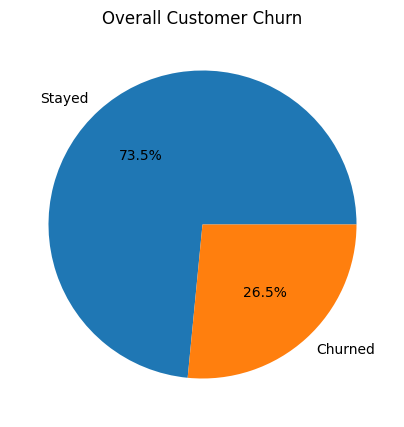

In [ ]:
import matplotlib.pyplot as plt

stay_customers = total_customers - churn_customers

plt.figure(figsize=(5,5))
plt.pie(
    [stay_customers, churn_customers],
    labels=["Stayed", "Churned"],
    autopct="%1.1f%%"
)

plt.title("Overall Customer Churn")
plt.show()

In [ ]:
# Features and Target
X = data.drop("Churn", axis=1)
y = data["Churn"]

In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [ ]:
# Logistic Regression Model
lr = LogisticRegression(max_iter=2000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [ ]:
# Random Forest Model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [ ]:
# Cross Validation
cv_lr = cross_val_score(lr, X, y, cv=5)
cv_rf = cross_val_score(rf, X, y, cv=5)

print("\nCross Validation Results")
print("Logistic Regression:", cv_lr.mean())
print("Random Forest:", cv_rf.mean())



Cross Validation Results
Logistic Regression: 0.8027837481450415
Random Forest: 0.7871661074908058


In [ ]:
# Logistic Regression Metrics
print("\nLogistic Regression Results")

print("Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print("Precision:",
      precision_score(y_test, y_pred_lr))

print("Recall:",
      recall_score(y_test, y_pred_lr))

print("F1 Score:",
      f1_score(y_test, y_pred_lr))

print("ROC-AUC:",
      roc_auc_score(y_test, y_pred_lr))


Logistic Regression Results
Accuracy: 0.8161816891412349
Precision: 0.6792452830188679
Recall: 0.579088471849866
F1 Score: 0.6251808972503617
ROC-AUC: 0.7403164366971338


In [ ]:
# Random Forest Metrics
print("\nRandom Forest Results")

print("Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("Precision:",
      precision_score(y_test, y_pred_rf))

print("Recall:",
      recall_score(y_test, y_pred_rf))

print("F1 Score:",
      f1_score(y_test, y_pred_rf))

print("ROC-AUC:",
      roc_auc_score(y_test, y_pred_rf))


Random Forest Results
Accuracy: 0.7955997161107168
Precision: 0.6591760299625468
Recall: 0.4718498659517426
F1 Score: 0.55
ROC-AUC: 0.6920060140569524


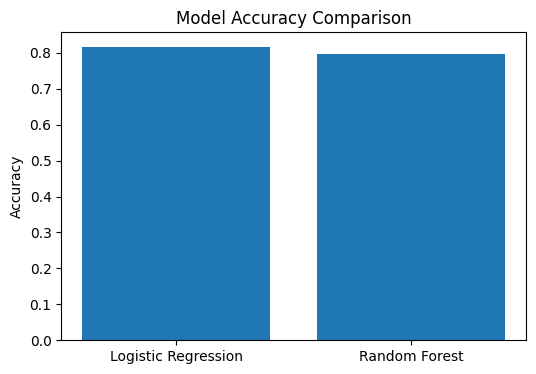

In [ ]:
# Accuracy Comparison Graph
models = [
    "Logistic Regression",
    "Random Forest"
]

accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_rf)
]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()



Feature Importance
             Feature  Importance
18      TotalCharges    0.189992
17    MonthlyCharges    0.177867
4             tenure    0.157428
14          Contract    0.077357
16     PaymentMethod    0.050379
8     OnlineSecurity    0.047432
11       TechSupport    0.044190
0             gender    0.028117
9       OnlineBackup    0.027067
7    InternetService    0.026444
15  PaperlessBilling    0.024917
2            Partner    0.023864
6      MultipleLines    0.023131
10  DeviceProtection    0.021012
3         Dependents    0.020709
1      SeniorCitizen    0.020354
13   StreamingMovies    0.017737
12       StreamingTV    0.016749
5       PhoneService    0.005254


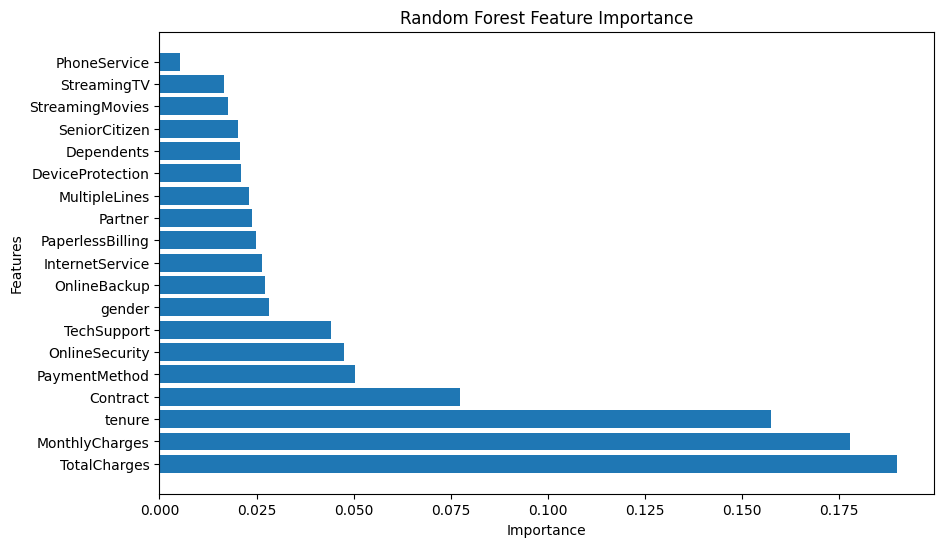

In [ ]:
# ==================================
# Feature Importance (Interpretation)
# ==================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance")
print(feature_importance)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()



Bias Analysis by Gender
Male Churn Rate: 0.2616033755274262
Female Churn Rate: 0.26920871559633025


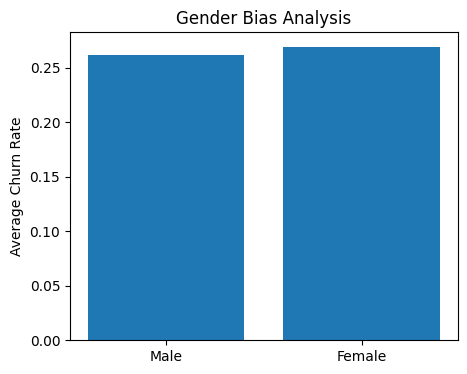

In [ ]:
# ==================================
# Bias Analysis
# ==================================

print("\nBias Analysis by Gender")

male = data[data["gender"] == 1]
female = data[data["gender"] == 0]

male_churn = male["Churn"].mean()
female_churn = female["Churn"].mean()

print("Male Churn Rate:", male_churn)
print("Female Churn Rate:", female_churn)

plt.figure(figsize=(5,4))

plt.bar(
    ["Male", "Female"],
    [male_churn, female_churn]
)

plt.title("Gender Bias Analysis")
plt.ylabel("Average Churn Rate")
plt.show()


In [ ]:

# ==================================
# Mitigation Recommendations
# ==================================

print("\nMitigation Recommendations")
print("1. Balance data across groups.")
print("2. Monitor model fairness regularly.")
print("3. Remove sensitive attributes if not required.")
print("4. Evaluate model performance separately for each group.")
print("5. Retrain model periodically to reduce bias.")

print("\nProject Completed Successfully")


Mitigation Recommendations
1. Balance data across groups.
2. Monitor model fairness regularly.
3. Remove sensitive attributes if not required.
4. Evaluate model performance separately for each group.
5. Retrain model periodically to reduce bias.

Project Completed Successfully


In [ ]:
# ==================================
# Manual Prediction
# ==================================

gender = input("Enter Gender (Male/Female): ")
senior = input("Senior Citizen (Yes/No): ")
partner = input("Partner (Yes/No): ")
dependents = input("Dependents (Yes/No): ")

gender = 1 if gender.lower() == "male" else 0
senior = 1 if senior.lower() == "yes" else 0
partner = 1 if partner.lower() == "yes" else 0
dependents = 1 if dependents.lower() == "yes" else 0

tenure = int(input("Tenure (months): "))
monthly = float(input("Monthly Charges: "))
total = float(input("Total Charges: "))

new_customer = [[
    gender,
    senior,
    partner,
    dependents,
    tenure,
    1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 2,
    monthly,
    total
]]

prediction = lr.predict(new_customer)

if prediction[0] == 1:
    print("Customer will CHURN")
else:
    print("Customer will STAY")

Enter Gender (Male/Female): Female
Senior Citizen (Yes/No): no
Partner (Yes/No): no
Dependents (Yes/No): yes
Tenure (months): 45
Monthly Charges: 20
Total Charges: 3000
Customer will STAY


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
